In [2]:
import numpy as np
import pandas as pd

In [3]:
filepath = 'house.csv'
df = pd.read_csv(filepath)

In [4]:
df.head(10)

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.000
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.000
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.000
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.000
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.000
5,2073.802250,5.0,1986,Kanpur,Residential Lane,Semi-Furnished,Apartment,No,470693.000
6,2103.042886,3.0,2020,Indore,Corner Plot,NaN,Apartment,No,552164.000
7,4316.818615,6.0,2008,Lucknow,Corner Plot,Semi-Furnished,Apartment,No,988286.819
8,2520.167537,4.0,2019,Prayagraj,Residential Lane,Semi-Furnished,Apartment,No,583210.000
9,2382.194887,3.0,2017,Jaipur,Gated Society,Semi-Furnished,Independent House,Yes,694155.000


In [5]:
missing = df.isnull().sum()
percent = (missing/len(df))*100
print("missing :",missing)
print("percent :",percent)

print("drop values :",df.dropna(inplace=True))

print("duplicate values : ",df.duplicated().sum())

missing : Area_SqFt        33
Rooms            33
Build_Year        0
Location          0
Street_Type       0
Furnishing       33
Property_Type     0
Has_Pool          0
Price             0
dtype: int64
percent : Area_SqFt        2.935943
Rooms            2.935943
Build_Year       0.000000
Location         0.000000
Street_Type      0.000000
Furnishing       2.935943
Property_Type    0.000000
Has_Pool         0.000000
Price            0.000000
dtype: float64
drop values : None
duplicate values :  0


In [6]:
print(df.describe)

target = df['Price']
print("mean :",target.mean())
print("min :",target.min())
print("max :",target.max())
print("median :",target.median())

<bound method NDFrame.describe of         Area_SqFt  Rooms  Build_Year   Location       Street_Type  \
0     2473.192784    4.0        1992     Jaipur  Residential Lane   
1     2353.472711    4.0        2006     Indore       Corner Plot   
2     2212.222005    3.0        2012     Jaipur    Highway Facing   
3     2823.886596    6.0        1993    Lucknow         Main Road   
4     1869.648721    5.0        2012     Jaipur       Corner Plot   
...           ...    ...         ...        ...               ...   
1118  1465.758301    5.0        1990    Lucknow     Gated Society   
1119  2461.048417    7.0        1988      Noida       Corner Plot   
1120  3558.174078    7.0        1989     Kanpur    Highway Facing   
1121  2179.880978    4.0        2011  Prayagraj  Residential Lane   
1123  3022.318426    4.0        2011   Gurugram  Residential Lane   

          Furnishing      Property_Type Has_Pool     Price  
0          Furnished          Apartment       No  568486.0  
1        Unfurn

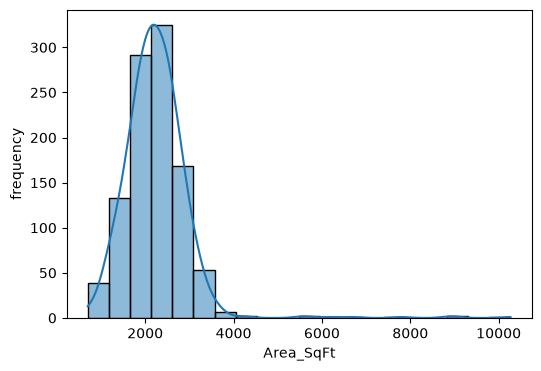

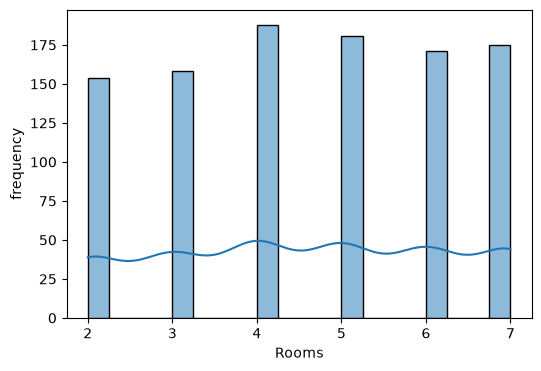

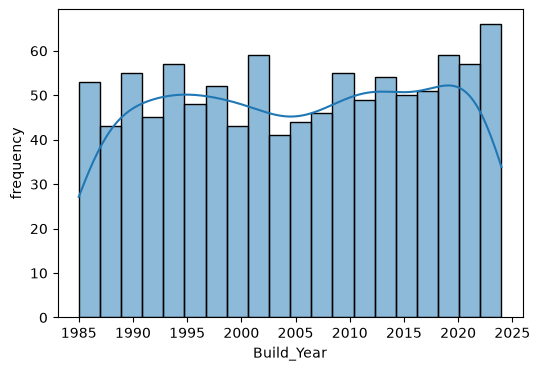

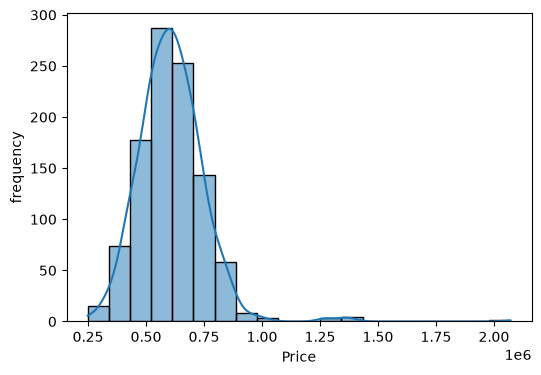

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = ['Area_SqFt',
           'Rooms',
           'Build_Year',
           'Price']

for col in columns :
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.show()

Index(['Location', 'Street_Type', 'Furnishing', 'Property_Type', 'Has_Pool'], dtype='str')


C:\Users\Asus\AppData\Local\Temp\ipykernel_12564\3880632161.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_values = df.select_dtypes(include='object').columns


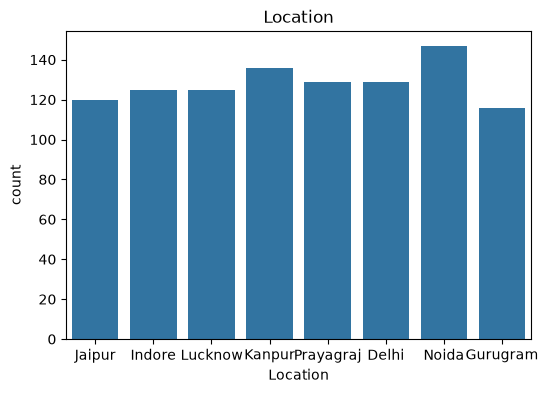

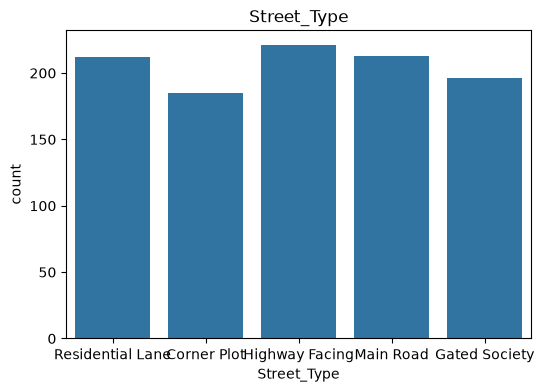

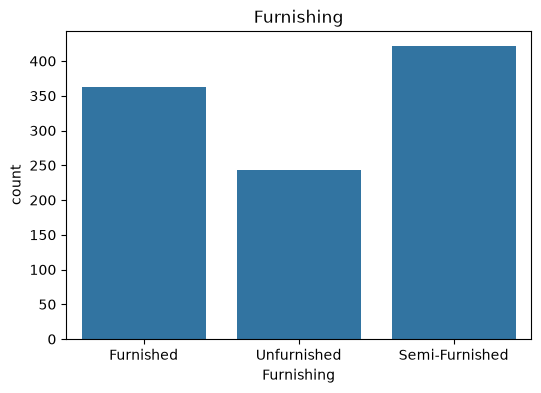

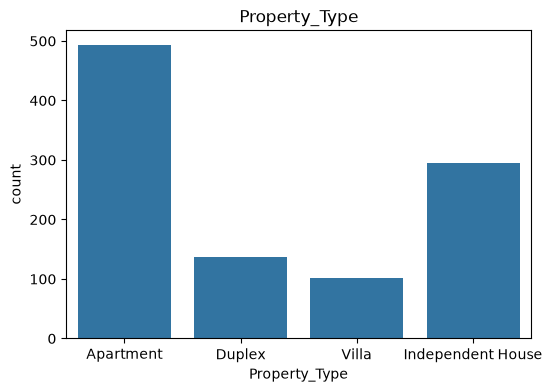

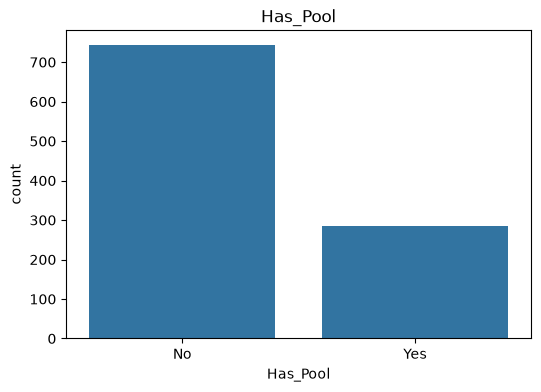

In [8]:
cat_values = df.select_dtypes(include='object').columns
print(cat_values)

columns = ['Location', 'Street_Type', 'Furnishing', 'Property_Type', 'Has_Pool']

for col in columns:
  plt.figure(figsize=(6,4))
  sns.countplot(x=col, data=df)
  plt.title(col)
  plt.xlabel(col)
  plt.ylabel('count')
  plt.show()

In [9]:
#Independent features
x = df.drop('Price', axis=1)
#dependet features
y = df['Price']
print("Independent columns :",x.columns)
print("Dependent Columns :",y.name)

Independent columns : Index(['Area_SqFt', 'Rooms', 'Build_Year', 'Location', 'Street_Type',
       'Furnishing', 'Property_Type', 'Has_Pool'],
      dtype='str')
Dependent Columns : Price


In [13]:
from sklearn.preprocessing import StandardScaler

x = pd.get_dummies(x)
columns = x.columns.tolist()
print(columns)

num_col = ['Area_SqFt', 'Rooms', 'Build_Year']

scaler = StandardScaler()
x[num_col] = scaler.fit_transform(x[num_col])

print(x[num_col])


['Area_SqFt', 'Rooms', 'Build_Year', 'Location_Delhi', 'Location_Gurugram', 'Location_Indore', 'Location_Jaipur', 'Location_Kanpur', 'Location_Lucknow', 'Location_Noida', 'Location_Prayagraj', 'Street_Type_Corner Plot', 'Street_Type_Gated Society', 'Street_Type_Highway Facing', 'Street_Type_Main Road', 'Street_Type_Residential Lane', 'Furnishing_Furnished', 'Furnishing_Semi-Furnished', 'Furnishing_Unfurnished', 'Property_Type_Apartment', 'Property_Type_Duplex', 'Property_Type_Independent House', 'Property_Type_Villa', 'Has_Pool_No', 'Has_Pool_Yes']
      Area_SqFt     Rooms  Build_Year
0      0.314967 -0.338163   -1.110003
1      0.154127 -0.338163    0.077911
2     -0.035639 -0.934888    0.587017
3      0.786113  0.855286   -1.025152
4     -0.495875  0.258561    0.587017
...         ...       ...         ...
1118  -1.038489  0.258561   -1.279704
1119   0.298652  1.452011   -1.449406
1120   1.772606  1.452011   -1.364555
1121  -0.079088 -0.338163    0.502166
1123   1.052700 -0.338163  

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

print("x_train :",x_train.shape)
print("x_test :",x_test.shape)
print("y_train :",y_train.shape)
print("y_test :",y_test.shape)

x_train : (821, 25)
x_test : (206, 25)
y_train : (821,)
y_test : (206,)


In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](25,)","[121270.26, 30678.42, 16350.36,..., 62562.94,-17309.83, 17309.83]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](25,)","['Area_SqFt','Rooms','Build_Year',...,'Property_Type_Villa','Has_Pool_No', 'Has_Pool_Yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.394e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,25
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)


In [50]:
y_pred = model.predict(x_test)
print(y_pred[:10])

print("1st 10 prediction values ")
print(y_test.iloc[:10])

[423256.98888593 690207.03112035 454652.95826201 404563.97735997
 605937.98960258 670916.01603384 679814.02422458 534602.01429276
 674802.99942726 498473.9905957 ]
1st 10 prediction values 
469    423257.0
580    690207.0
426    454653.0
115    404564.0
464    605938.0
461    670916.0
175    679814.0
261    534602.0
721    674803.0
591    498474.0
Name: Price, dtype: float64


In [67]:
print(len(y_test))
print(len(y_pred))

206
206


In [68]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("r2 score :",r2)


r2 score : -21.09889780964373


In [18]:
import joblib

joblib.dump(model,"house.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(columns,"columns.pkl")
joblib.dump(num_col,"num_col.pkl")

print("saved successfully")


saved successfully
